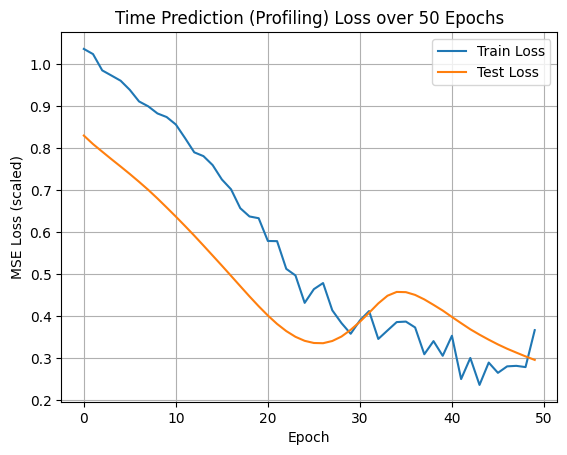

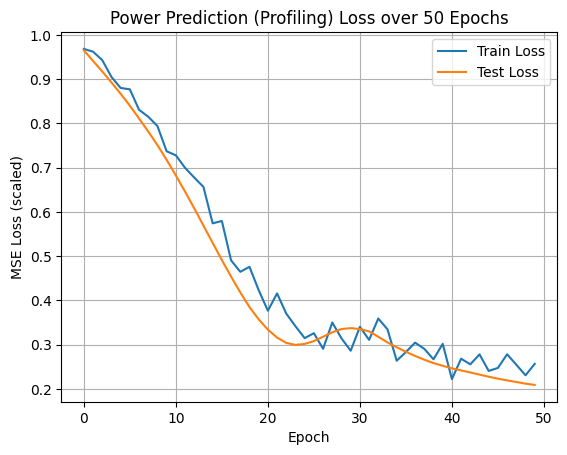

['power_target_scaler.pkl']

In [9]:
import pandas as pd
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---- Configuration ----
PROFILING_CSV = "power_profile_20250501_171014.csv"
NEW_WORKLOAD_CSV = "power_profile_new_workload.csv"  # replace with your new CSV path
FEATURE_COLUMNS = ['CPU_Cores', 'CPU_Freq_MHz', 'GPU_Freq_MHz']
TARGET_TIME_COL = 'Avg_Time_s'
TARGET_POWER_COL = 'Avg_Total_Power_mW'

# ---- 1. Profiling Model Training ----
# Load profiling data
df_prof = pd.read_csv(PROFILING_CSV)
# Prepare features and targets
X_prof = df_prof[FEATURE_COLUMNS].values
y_time_prof = df_prof[TARGET_TIME_COL].values.reshape(-1, 1)
y_power_prof = (df_prof[TARGET_POWER_COL] / 1000.0).values.reshape(-1, 1)  # convert mW to W

# Split into train/test
X_train_prof, X_test_prof, y_time_train, y_time_test, y_power_train, y_power_test = train_test_split(
    X_prof, y_time_prof, y_power_prof, test_size=0.2, random_state=42)

# Fit scalers on profiling data
feature_scaler = StandardScaler().fit(X_train_prof)
time_scaler = StandardScaler().fit(y_time_train)
power_scaler = StandardScaler().fit(y_power_train)

# Scale profiling data
X_train_prof_scaled = feature_scaler.transform(X_train_prof)
X_test_prof_scaled = feature_scaler.transform(X_test_prof)
y_time_train_scaled = time_scaler.transform(y_time_train)
y_time_test_scaled = time_scaler.transform(y_time_test)
y_power_train_scaled = power_scaler.transform(y_power_train)
y_power_test_scaled = power_scaler.transform(y_power_test)

# Convert to tensors
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32)

X_train_tensor = to_tensor(X_train_prof_scaled)
X_test_tensor = to_tensor(X_test_prof_scaled)
y_time_train_tensor = to_tensor(y_time_train_scaled)
y_time_test_tensor = to_tensor(y_time_test_scaled)
y_power_train_tensor = to_tensor(y_power_train_scaled)
y_power_test_tensor = to_tensor(y_power_test_scaled)

# Define the NN architecture
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(len(FEATURE_COLUMNS), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

# Training function
def train_model(model, optimizer, X_tr, y_tr, X_te, y_te, epochs, title):
    criterion = nn.MSELoss()
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_loss = criterion(model(X_te), y_te).item()
            test_losses.append(test_loss)

    # Plot losses
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title(f"{title} Loss over {epochs} Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss (scaled)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Instantiate and train profiling models
model_time_prof = SimpleNN()
model_power_prof = SimpleNN()
opt_time_prof = optim.Adam(model_time_prof.parameters(), lr=0.001)
opt_power_prof = optim.Adam(model_power_prof.parameters(), lr=0.001)

train_model(model_time_prof, opt_time_prof,
            X_train_tensor, y_time_train_tensor,
            X_test_tensor, y_time_test_tensor,
            epochs=50, title="Time Prediction (Profiling)")

train_model(model_power_prof, opt_power_prof,
            X_train_tensor, y_power_train_tensor,
            X_test_tensor, y_power_test_tensor,
            epochs=50, title="Power Prediction (Profiling)")

# Save profiling models and scalers
torch.save(model_time_prof.state_dict(), "model_time_reference.pt")
torch.save(model_power_prof.state_dict(), "model_power_reference.pt")
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(time_scaler, "time_target_scaler.pkl")
joblib.dump(power_scaler, "power_target_scaler.pkl")
